<a href="https://colab.research.google.com/github/akverma1210/Anand-demo/blob/main/Copy_of_wesad_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
orvile_wesad_wearable_stress_affect_detection_dataset_path = kagglehub.dataset_download('orvile/wesad-wearable-stress-affect-detection-dataset')

print('Data source import complete.')

Using Colab cache for faster access to the 'wesad-wearable-stress-affect-detection-dataset' dataset.
Data source import complete.


In [ ]:
import os

# Find the actual path
print("Dataset path:", orvile_wesad_wearable_stress_affect_detection_dataset_path)
print("\nContents:")
for item in os.listdir(orvile_wesad_wearable_stress_affect_detection_dataset_path):
    print(" ", item)

Dataset path: /kaggle/input/wesad-wearable-stress-affect-detection-dataset

Contents:
  WESAD


In [ ]:
import os

base_path = orvile_wesad_wearable_stress_affect_detection_dataset_path

print("Contents:")
for item in sorted(os.listdir(base_path)):
    print(" ", item)

Contents:
  WESAD


In [ ]:
import os

base_path = '/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD'

print("Contents:")
for item in sorted(os.listdir(base_path)):
    print(" ", item)

Contents:
  S10
  S11
  S13
  S14
  S15
  S16
  S17
  S2
  S3
  S4
  S5
  S6
  S7
  S8
  S9
  wesad_readme.pdf


In [ ]:
base_path = '/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD'

print("Subjects found:", sorted([x for x in os.listdir(base_path) if x.startswith('S')]))

Subjects found: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import scipy.signal
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GRU, Dense, Dropout, Input,
                                      Multiply, Softmax, Lambda, Permute,
                                      RepeatVector, Flatten, Activation)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')


In [ ]:
BINARY_LABELS = {1: 0, 3: 0, 2: 1}  # Baseline & Amusement = 0, Stress = 1
VALID_LABELS = [1, 2, 3]
TARGET_FS = 4
WINDOW_SEC = 30
STEP_SEC = 10

In [ ]:
def inspect_subject_labels(subject_path):
    """Inspect labels in the data"""
    with open(subject_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')

    labels = data['label']
    unique_labels = np.unique(labels)
    label_counts = {}

    for label in unique_labels:
        count = np.sum(labels == label)
        duration = count / 700 / 60
        label_counts[label] = (count, duration)

    return label_counts

In [ ]:
def load_wesad_data(subject_path):
    """Load WESAD pickle file"""
    with open(subject_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')
    return data


In [ ]:

def align_wrist_signals(wrist_data, labels, target_fs=4):
    """
    Align wrist signals to unified 4 Hz sampling rate
    - ACC: 32 Hz → 4 Hz
    - BVP: 64 Hz → 4 Hz
    - EDA: 4 Hz (unchanged)
    - TEMP: 4 Hz (unchanged)
    """
    duration_sec = len(labels) / 700
    target_len = int(duration_sec * target_fs)

    acc = wrist_data['ACC']
    bvp = wrist_data['BVP']
    eda = wrist_data['EDA']
    temp = wrist_data['TEMP']

    # Resample all to target frequency
    acc_resampled = scipy.signal.resample(acc, target_len, axis=0) if acc.ndim == 2 else scipy.signal.resample(acc, target_len).reshape(-1, 1)
    bvp_resampled = scipy.signal.resample(bvp, target_len)
    eda_resampled = scipy.signal.resample(eda, target_len)
    temp_resampled = scipy.signal.resample(temp, target_len)
    labels_resampled = scipy.signal.resample(labels, target_len)
    labels_resampled = np.round(labels_resampled).astype(int)

    # Combine: ACC (3) + BVP (1) + EDA (1) + TEMP (1) = 6 features
    combined_data = np.hstack([
        acc_resampled,
        bvp_resampled.reshape(-1, 1),
        eda_resampled.reshape(-1, 1),
        temp_resampled.reshape(-1, 1)
    ])

    return combined_data, labels_resampled


In [ ]:
def create_windows(data, labels, window_size, step_size, valid_labels):
    """Create sliding windows from data"""
    X = []
    y = []

    if len(data) < window_size:
        return np.array([]), np.array([])

    num_steps = (len(data) - window_size) // step_size + 1

    for i in range(num_steps):
        start = i * step_size
        end = start + window_size

        if end > len(data):
            break

        window_data = data[start:end]
        window_label = labels[end - 1]

        if window_label in valid_labels:
            X.append(window_data)
            y.append(BINARY_LABELS[window_label])

    return np.array(X), np.array(y)


In [ ]:
def preprocess_subject(subject_path, target_fs=TARGET_FS, window_sec=WINDOW_SEC, step_sec=STEP_SEC):
    """Process single subject"""
    try:
        raw_data = load_wesad_data(subject_path)
        wrist_data = raw_data['signal']['wrist']
        labels = raw_data['label']

        aligned_data, aligned_labels = align_wrist_signals(wrist_data, labels, target_fs)

        scaler = StandardScaler()
        normalized_data = scaler.fit_transform(aligned_data)

        window_pts = int(window_sec * target_fs)
        step_pts = int(step_sec * target_fs)

        X, y = create_windows(normalized_data, aligned_labels, window_pts, step_pts, VALID_LABELS)

        return X, y
    except Exception as e:
        print(f"  Error: {e}")
        return np.array([]), np.array([])


In [ ]:
base_path = '/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD'
subjects = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

In [ ]:
for subj in subjects:
    subj_path = os.path.join(base_path, subj, f'{subj}.pkl')
    if os.path.exists(subj_path):
        label_info = inspect_subject_labels(subj_path)
        print(f"\n{subj}:")
        for label, (count, duration) in sorted(label_info.items()):
            label_name = {1: "Baseline", 2: "Stress", 3: "Amusement", 0: "Transient"}.get(label, "Unknown")
            print(f"  Label {label} ({label_name:12}): {count:6,} samples = {duration:5.1f} min")



S2:
  Label 0 (Transient   ): 2,142,701 samples =  51.0 min
  Label 1 (Baseline    ): 800,800 samples =  19.1 min
  Label 2 (Stress      ): 430,500 samples =  10.2 min
  Label 3 (Amusement   ): 253,400 samples =   6.0 min
  Label 4 (Unknown     ): 537,599 samples =  12.8 min
  Label 6 (Unknown     ): 45,500 samples =   1.1 min
  Label 7 (Unknown     ): 44,800 samples =   1.1 min

S3:
  Label 0 (Transient   ): 2,345,699 samples =  55.8 min
  Label 1 (Baseline    ): 798,000 samples =  19.0 min
  Label 2 (Stress      ): 448,000 samples =  10.7 min
  Label 3 (Amusement   ): 262,500 samples =   6.2 min
  Label 4 (Unknown     ): 546,001 samples =  13.0 min
  Label 5 (Unknown     ): 51,100 samples =   1.2 min
  Label 6 (Unknown     ): 46,900 samples =   1.1 min
  Label 7 (Unknown     ): 46,900 samples =   1.1 min

S4:
  Label 0 (Transient   ): 2,314,199 samples =  55.1 min
  Label 1 (Baseline    ): 810,601 samples =  19.3 min
  Label 2 (Stress      ): 444,500 samples =  10.6 min
  Label 3 (A

In [ ]:
all_X = []
all_y = []
subject_indices = []

for subj in subjects:
    subj_path = os.path.join(base_path, subj, f'{subj}.pkl')
    if os.path.exists(subj_path):
        X_sub, y_sub = preprocess_subject(subj_path)

        if len(X_sub) > 0:
            all_X.append(X_sub)
            all_y.append(y_sub)
            subject_indices.extend([subj] * len(X_sub))

            stress_count = np.sum(y_sub)
            non_stress_count = len(y_sub) - stress_count
            print(f"✓ {subj}: {len(X_sub):3d} windows | Stress: {stress_count:2d} | Non-stress: {non_stress_count:2d}")


✓ S2: 212 windows | Stress: 61 | Non-stress: 151
✓ S3: 215 windows | Stress: 64 | Non-stress: 151
✓ S4: 216 windows | Stress: 63 | Non-stress: 153
✓ S5: 221 windows | Stress: 64 | Non-stress: 157
✓ S6: 221 windows | Stress: 65 | Non-stress: 156
✓ S7: 220 windows | Stress: 64 | Non-stress: 156
✓ S8: 221 windows | Stress: 67 | Non-stress: 154
✓ S9: 220 windows | Stress: 64 | Non-stress: 156
✓ S10: 227 windows | Stress: 72 | Non-stress: 155
✓ S11: 223 windows | Stress: 68 | Non-stress: 155
✓ S13: 222 windows | Stress: 66 | Non-stress: 156
✓ S14: 222 windows | Stress: 67 | Non-stress: 155
✓ S15: 223 windows | Stress: 69 | Non-stress: 154
✓ S16: 222 windows | Stress: 68 | Non-stress: 154
✓ S17: 227 windows | Stress: 72 | Non-stress: 155


In [ ]:
if len(all_X) == 0:
    print("ERROR: No data loaded!")
    exit()

X_final = np.concatenate(all_X, axis=0)
y_final = np.concatenate(all_y, axis=0)


In [ ]:
print(f"TOTAL SAMPLES: {len(X_final)}")
print(f"Feature shape: {X_final.shape}")
print(f"\nClass distribution:")
print(f"  Stress (1): {np.sum(y_final):5d} ({np.sum(y_final)/len(y_final)*100:.1f}%)")
print(f"  Non-stress (0): {len(y_final) - np.sum(y_final):5d} ({(1 - np.sum(y_final)/len(y_final))*100:.1f}%)")
print(f"  Imbalance ratio: {np.sum(y_final) / (len(y_final) - np.sum(y_final)):.3f}")

TOTAL SAMPLES: 3312
Feature shape: (3312, 120, 6)

Class distribution:
  Stress (1):   994 (30.0%)
  Non-stress (0):  2318 (70.0%)
  Imbalance ratio: 0.429


# Leave-One-Subject-Out (LOSO) Cross-Validation

Proper evaluation: each fold holds out one subject entirely — the model never sees that subject during training.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Leave-One-Subject-Out Cross-Validation (LOSO-CV)
# Each subject is held out once as the test set; the rest train.
# ─────────────────────────────────────────────────────────────────

unique_subjects = sorted(list(set(subject_indices)))
subject_indices_arr = np.array(subject_indices)

loso_results = []   # one dict per fold

for test_subj in unique_subjects:
    test_mask  = (subject_indices_arr == test_subj)
    train_mask = ~test_mask

    X_tr, y_tr = X_final[train_mask], y_final[train_mask]
    X_te, y_te = X_final[test_mask],  y_final[test_mask]

    if len(np.unique(y_te)) < 2:
        print(f"  Skipping {test_subj} – only one class in test set")
        continue

    loso_results.append({
        'subject': test_subj,
        'X_tr': X_tr, 'y_tr': y_tr,
        'X_te': X_te, 'y_te': y_te,
        'n_train': len(X_tr),
        'n_test':  len(X_te),
    })
    print(f"Fold {test_subj:>4s}: train={len(X_tr):4d}  test={len(X_te):3d}  "
          f"stress_test={int(np.sum(y_te)):3d}/{len(y_te):3d}")

print(f"\nTotal folds: {len(loso_results)}")


Fold  S10: train=3085  test=227  stress_test= 72/227
Fold  S11: train=3089  test=223  stress_test= 68/223
Fold  S13: train=3090  test=222  stress_test= 66/222
Fold  S14: train=3090  test=222  stress_test= 67/222
Fold  S15: train=3089  test=223  stress_test= 69/223
Fold  S16: train=3090  test=222  stress_test= 68/222
Fold  S17: train=3085  test=227  stress_test= 72/227
Fold   S2: train=3100  test=212  stress_test= 61/212
Fold   S3: train=3097  test=215  stress_test= 64/215
Fold   S4: train=3096  test=216  stress_test= 63/216
Fold   S5: train=3091  test=221  stress_test= 64/221
Fold   S6: train=3091  test=221  stress_test= 65/221
Fold   S7: train=3092  test=220  stress_test= 64/220
Fold   S8: train=3091  test=221  stress_test= 67/221
Fold   S9: train=3092  test=220  stress_test= 64/220

Total folds: 15


# Attention-GRU Model

A temporal attention layer sits between the two GRU stacks, letting the model up-weight the most stress-relevant time-steps.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Attention mechanism (Bahdanau-style temporal attention)
# ─────────────────────────────────────────────────────────────────

def build_attention_gru(input_shape):
    """
    Architecture
    ────────────
    Input → GRU(64, return_sequences=True)
          → Temporal Attention (learned soft-max weights over T steps)
          → context vector (weighted sum)
          → GRU(32, return_sequences=False)  [on attended sequence]
          → Dense(16, relu) → Dense(1, sigmoid)
    """
    inp = Input(shape=input_shape, name='input')

    # First GRU – produces a hidden state per time-step
    gru1 = GRU(64, return_sequences=True, name='gru1')(inp)
    gru1 = Dropout(0.3, name='drop1')(gru1)

    # ── Attention ──────────────────────────────────────────────────
    # score(t) = tanh(W · h_t)  →  softmax over T  →  context = Σ α_t h_t
    attn_scores = Dense(1, activation='tanh', use_bias=False, name='attn_score')(gru1)   # (B, T, 1)
    attn_weights = Softmax(axis=1, name='attn_weights')(attn_scores)                      # (B, T, 1)
    context = Multiply(name='attn_context')([gru1, attn_weights])                         # (B, T, 64)
    # ──────────────────────────────────────────────────────────────

    # Second GRU reads the attention-weighted sequence
    gru2 = GRU(32, return_sequences=False, name='gru2')(context)
    gru2 = Dropout(0.3, name='drop2')(gru2)

    fc   = Dense(16, activation='relu', name='fc')(gru2)
    fc   = Dropout(0.2, name='drop3')(fc)
    out  = Dense(1, activation='sigmoid', name='output')(fc)

    model = Model(inputs=inp, outputs=out, name='AttentionGRU')
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

input_shape = (X_final.shape[1], X_final.shape[2])
print(f"Model input shape: {input_shape}")
demo_model = build_attention_gru(input_shape)
demo_model.summary()


Model input shape: (120, 6)


Model: "AttentionGRU"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 120, 6)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru1 (GRU)          │ (None, 120, 64)   │     13,824 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 120, 64)   │          0 │ gru1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_score (Dense)  │ (None, 120, 1)    │         64 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weights        │ (None, 120, 1)    │          0 │ attn_score[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_context        │ (None, 120, 64)   │          0 │ drop1[0][0],      │
│ (Multiply)          │                   │            │ attn_weights[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru2 (GRU)          │ (None, 32)        │      9,408 │ attn_context[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 32)        │          0 │ gru2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc (Dense)          │ (None, 16)        │        528 │ drop2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop3 (Dropout)     │ (None, 16)        │          0 │ fc[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ drop3[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,841 (93.13 KB)

 Trainable params: 23,841 (93.13 KB)

 Non-trainable params: 0 (0.00 B)

# Run LOSO Training

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

fold_metrics = []   # accuracy, auc, f1 per fold

for fold in loso_results:
    subj = fold['subject']
    X_tr, y_tr = fold['X_tr'], fold['y_tr']
    X_te, y_te = fold['X_te'], fold['y_te']

    # Per-fold class weights (computed only from training subjects)
    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_dict = {0: cw[0], 1: cw[1]}

    model = build_attention_gru(input_shape)

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=30,
        batch_size=32,
        class_weight=cw_dict,
        callbacks=[early_stop],
        verbose=0
    )

    y_prob = model.predict(X_te, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    acc   = np.mean(y_pred == y_te)
    auc   = roc_auc_score(y_te, y_prob)
    rep   = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    f1    = rep['macro avg']['f1-score']

    fold['model']   = model
    fold['history'] = history
    fold['y_pred']  = y_pred
    fold['y_prob']  = y_prob
    fold_metrics.append({'subject': subj, 'accuracy': acc, 'auc': auc, 'f1': f1})

    print(f"{subj:>4s}  acc={acc*100:5.1f}%  auc={auc:.4f}  macro-f1={f1:.4f}")

print("\n─── LOSO Summary ───")
metrics_df = pd.DataFrame(fold_metrics)
print(metrics_df.set_index('subject').to_string())
print(f"\nMean ± std  acc={metrics_df.accuracy.mean()*100:.2f}% ± {metrics_df.accuracy.std()*100:.2f}%")
print(f"            auc={metrics_df.auc.mean():.4f} ± {metrics_df.auc.std():.4f}")
print(f"            f1 ={metrics_df.f1.mean():.4f} ± {metrics_df.f1.std():.4f}")


 S10  acc=100.0%  auc=1.0000  macro-f1=1.0000
 S11  acc= 68.6%  auc=0.8014  macro-f1=0.6200


 S13  acc= 92.8%  auc=1.0000  macro-f1=0.9189


 S14  acc= 63.5%  auc=0.5987  macro-f1=0.6164
 S15  acc= 99.6%  auc=0.9983  macro-f1=0.9948
 S16  acc= 77.5%  auc=1.0000  macro-f1=0.7687
 S17  acc= 61.7%  auc=0.6008  macro-f1=0.5955
  S2  acc= 92.5%  auc=0.9756  macro-f1=0.9141
  S3  acc= 62.8%  auc=0.7172  macro-f1=0.6152
  S4  acc=100.0%  auc=1.0000  macro-f1=1.0000
  S5  acc= 94.6%  auc=1.0000  macro-f1=0.9373
  S6  acc= 96.8%  auc=1.0000  macro-f1=0.9630
  S7  acc= 97.7%  auc=1.0000  macro-f1=0.9731
  S8  acc= 92.8%  auc=0.9901  macro-f1=0.9193
  S9  acc=100.0%  auc=1.0000  macro-f1=1.0000

─── LOSO Summary ───
         accuracy       auc        f1
subject                              
S10      1.000000  1.000000  1.000000
S11      0.686099  0.801423  0.620010
S13      0.927928  1.000000  0.918919
S14      0.635135  0.598652  0.616449
S15      0.995516  0.998306  0.994774
S16      0.774775  1.000000  0.768692
S17      0.616740  0.600806  0.595515
S2       0.924528  0.975573  0.914057
S3       0.627907  0.717198  0.615247
S4      

# Aggregate Evaluation (All Folds Combined)

=== Aggregate Classification Report ===
              precision    recall  f1-score   support

Not Stressed       0.95      0.85      0.90      2318
    Stressed       0.72      0.90      0.80       994

    accuracy                           0.87      3312
   macro avg       0.84      0.88      0.85      3312
weighted avg       0.88      0.87      0.87      3312



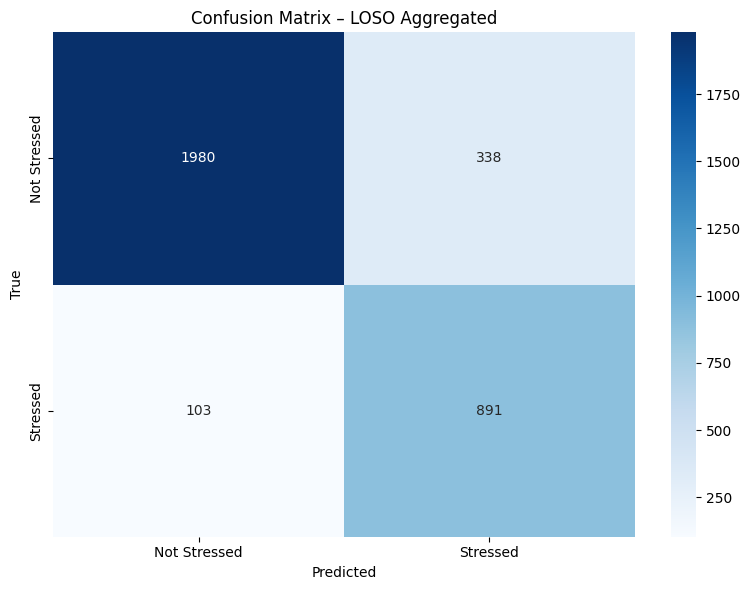

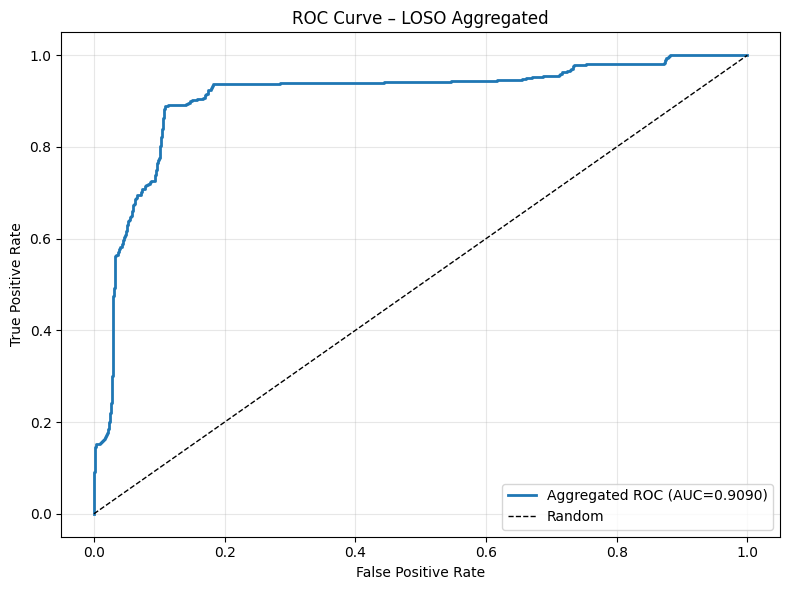

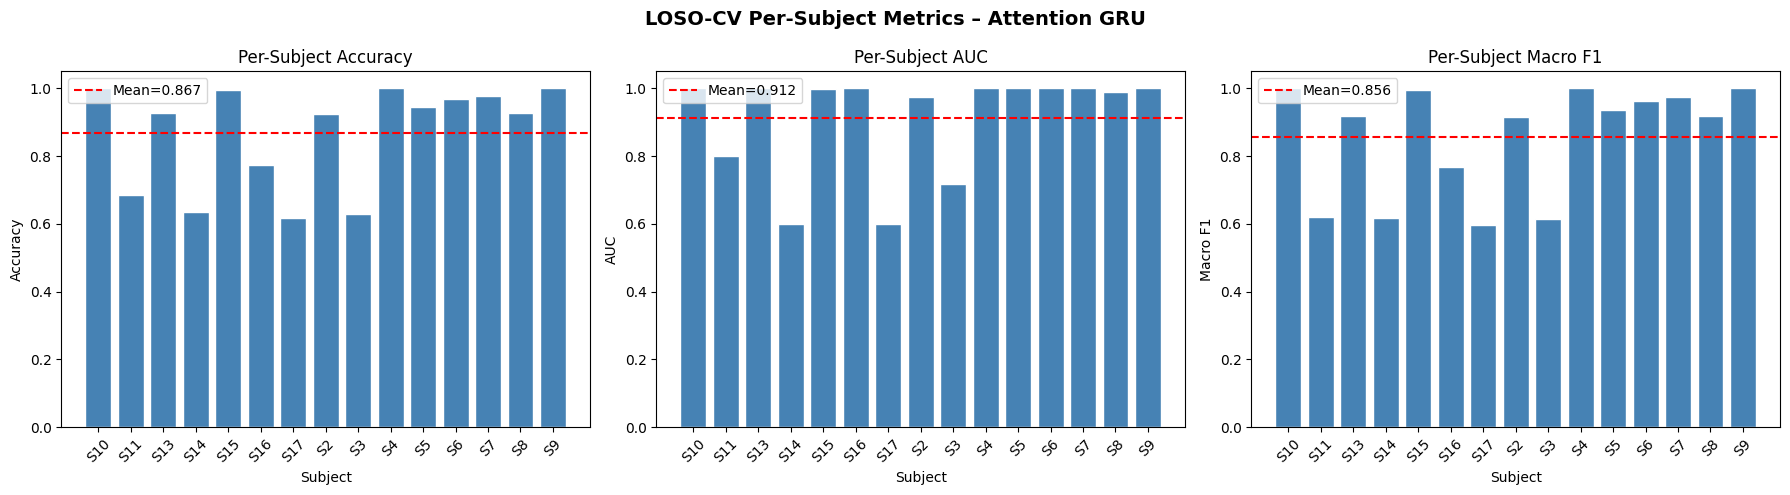

In [ ]:
all_y_true = np.concatenate([f['y_te']   for f in loso_results])
all_y_pred = np.concatenate([f['y_pred'] for f in loso_results])
all_y_prob = np.concatenate([f['y_prob'] for f in loso_results])

print("=== Aggregate Classification Report ===")
print(classification_report(all_y_true, all_y_pred, target_names=['Not Stressed', 'Stressed']))

# Confusion matrix
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Stressed', 'Stressed'],
            yticklabels=['Not Stressed', 'Stressed'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix – LOSO Aggregated')
plt.tight_layout(); plt.savefig('confusion_matrix_loso.png', dpi=300, bbox_inches='tight'); plt.show()

# ROC curve (aggregated)
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
auc_agg = roc_auc_score(all_y_true, all_y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Aggregated ROC (AUC={auc_agg:.4f})')
plt.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve – LOSO Aggregated'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_curve_loso.png', dpi=300, bbox_inches='tight'); plt.show()

# Per-subject bar chart
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for i, (metric, label) in enumerate([('accuracy','Accuracy'),('auc','AUC'),('f1','Macro F1')]):
    ax[i].bar(metrics_df['subject'], metrics_df[metric], color='steelblue', edgecolor='white')
    ax[i].axhline(metrics_df[metric].mean(), color='red', linestyle='--', label=f'Mean={metrics_df[metric].mean():.3f}')
    ax[i].set_title(f'Per-Subject {label}'); ax[i].set_xlabel('Subject'); ax[i].set_ylabel(label)
    ax[i].set_ylim(0, 1.05); ax[i].legend(); ax[i].tick_params(axis='x', rotation=45)
plt.suptitle('LOSO-CV Per-Subject Metrics – Attention GRU', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('loso_per_subject_metrics.png', dpi=300, bbox_inches='tight'); plt.show()


# Save Best-Fold Model

In [ ]:
best_fold = max(loso_results, key=lambda f: roc_auc_score(f['y_te'], f['y_prob']))
print(f"Best fold: {best_fold['subject']} (AUC={roc_auc_score(best_fold['y_te'], best_fold['y_prob']):.4f})")

best_fold['model'].save('wesad_attention_gru_best_fold.h5')

# Save inference config
config = {
    'TARGET_FS': TARGET_FS,
    'WINDOW_SEC': WINDOW_SEC,
    'STEP_SEC': STEP_SEC,
    'WINDOW_POINTS': int(WINDOW_SEC * TARGET_FS),
    'VALID_LABELS': VALID_LABELS,
    'BINARY_LABELS': BINARY_LABELS,
    'FEATURE_NAMES': ['ACC_X', 'ACC_Y', 'ACC_Z', 'BVP', 'EDA', 'TEMP'],
    'MODEL_INPUT_SHAPE': tuple(input_shape),
    'SAMPLING_RATES': {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4},
    'BEST_FOLD_SUBJECT': best_fold['subject'],
}
joblib.dump(config, 'config_inference.pkl')
joblib.dump(metrics_df, 'loso_metrics.pkl')
print("Saved: wesad_attention_gru_best_fold.h5, config_inference.pkl, loso_metrics.pkl")


Best fold: S10 (AUC=1.0000)
Saved: wesad_attention_gru_best_fold.h5, config_inference.pkl, loso_metrics.pkl


In [ ]:
print("done")

done
